In [21]:
!pip install ruts pandas textstat beautifulsoup4

In [22]:
import os
import pandas as pd
import textstat
from bs4 import BeautifulSoup
from tqdm import tqdm
from google.colab import drive

In [35]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
TEXTS_FOLDER = '/content/drive/MyDrive/Анализаторы/ims'

In [38]:
from google.colab import files
import os

# Создаем папку для текстов
os.makedirs('/content/texts', exist_ok=True)

# Запускаем загрузку (появится кнопка)
uploaded = files.upload()

# Переносим файлы в папку
for filename in uploaded.keys():
    os.rename(filename, f'/content/texts/{filename}')

print(f"Загружено {len(uploaded)} файлов")

Saving Belov_IMS_2018_rus.txt to Belov_IMS_2018_rus (3).txt
Saving Belova_IMS_2014_rus.txt to Belova_IMS_2014_rus (3).txt
Saving Boyarsky_IMS_2015_rus.txt to Boyarsky_IMS_2015_rus (3).txt
Saving Boyarsky_IMS_2019_rus.txt to Boyarsky_IMS_2019_rus (3).txt
Saving Chizhik_IMS_2021_rus.txt to Chizhik_IMS_2021_rus (3).txt
Saving ChizhikMelnikovaZakharov_IMS_2022.txt to ChizhikMelnikovaZakharov_IMS_2022 (3).txt
Saving Dubovik_IMS_2017_rus.txt to Dubovik_IMS_2017_rus (3).txt
Saving Gavrilkina_IMS_2023.txt to Gavrilkina_IMS_2023 (3).txt
Saving Godgildieva_IMS_2016_rus.txt to Godgildieva_IMS_2016_rus (3).txt
Saving Ivanchenko_IMS_2013_rus.txt to Ivanchenko_IMS_2013_rus (3).txt
Saving Khokhlova_IMS_2020_rus.txt to Khokhlova_IMS_2020_rus (3).txt
Saving MitrofanovaGolubev_IMS_2024_rus.txt to MitrofanovaGolubev_IMS_2024_rus (3).txt
Загружено 12 файлов


In [42]:
def clean_text(text):
    """Очистка текста от HTML и лишних пробелов"""
    soup = BeautifulSoup(text, 'html.parser')
    return ' '.join(soup.get_text(separator=' ').split())

def analyze_text(text):
    """Анализ текста с обработкой ошибок"""
    try:
        return {
            'words': len(text.split()),
            'sentences': textstat.sentence_count(text),
            'flesch': textstat.flesch_reading_ease(text),
            'smog': textstat.smog_index(text),
            'gunning_fog': textstat.gunning_fog(text),
            'difficult_words': textstat.difficult_words(text)
        }
    except:
        return None

def main():
    # Проверяем наличие папки
    if not os.path.exists(TEXTS_FOLDER):
        print(f"ОШИБКА: Папка {TEXTS_FOLDER} не найдена!")
        print("Сначала выполните ячейку загрузки файлов")
        return

    # Получаем список файлов
    files = [f for f in os.listdir(TEXTS_FOLDER) if f.endswith('.txt')]
    if not files:
        print("ОШИБКА: В папке нет .txt файлов!")
        return

    print(f"Найдено {len(files)} текстовых файлов. Начинаю анализ...")

    # Анализируем файлы
    results = []
    for filename in tqdm(files):
        filepath = os.path.join(TEXTS_FOLDER, filename)

        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                text = clean_text(f.read())
                if not text or len(text.split()) < 10:  # Минимум 10 слов
                    continue

                # Извлекаем автора и год из имени файла
                parts = filename.split('_')
                author = parts[0]
                year = next((p for p in parts if p.isdigit() and len(p) == 4), None)

                # Анализ текста
                analysis = analyze_text(text)
                if analysis:
                    analysis.update({
                        'filename': filename,
                        'author': author,
                        'year': year
                    })
                    results.append(analysis)
        except Exception as e:
            print(f"Ошибка при обработке {filename}: {str(e)}")

    # Сохраняем результаты
    if results:
        df = pd.DataFrame(results)
        output_file = '/content/text_analysis_results.csv'
        df.to_csv(output_file, index=False)

        print("\nРезультаты анализа:")
        print(df.head())

        # Предлагаем скачать файл
        from google.colab import files
        files.download(output_file)
    else:
        print("Не удалось проанализировать ни один файл")

# Запускаем анализ
main()

Найдено 12 текстовых файлов. Начинаю анализ...


100%|██████████| 12/12 [00:04<00:00,  2.42it/s]


Результаты анализа:
   words  sentences  flesch  smog  gunning_fog  difficult_words                filename                          author           year
0  3188      168      99.96  5.50      7.95           37           MitrofanovaGolubev_IMS_2024_rus.txt        MitrofanovaGolubev  2024
1  1185       60      99.49  5.34      8.10           18                    Khokhlova_IMS_2020_rus.txt                 Khokhlova  2020
2  1682       55      90.84  3.13     12.07           10                   Ivanchenko_IMS_2013_rus.txt                Ivanchenko  2013
3  2267      144     102.82  5.15      6.56           40                  Godgildieva_IMS_2016_rus.txt               Godgildieva  2016
4  1896       90     100.25  3.98      8.42            5         ChizhikMelnikovaZakharov_IMS_2022.txt  ChizhikMelnikovaZakharov  None


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

flesch -- индекс удобочитаемости
smog -- индекс сложности
gunning_fog -- индекс "туманности"


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Ваши данные
data = {
    'words': [3188, 1185, 1682, 2267, 1896],
    'sentences': [168, 60, 55, 144, 90],
    'flesch': [99.96, 99.49, 90.84, 102.82, 100.25],
    'smog': [5.50, 5.34, 3.13, 5.15, 3.98],
    'gunning_fog': [7.95, 8.10, 12.07, 6.56, 8.42],
    'difficult_words': [37, 18, 10, 40, 5],
    'filename': ['MitrofanovaGolubev_IMS_2024_rus.txt', 'Khokhlova_IMS_2020_rus.txt',
                'Ivanchenko_IMS_2013_rus.txt', 'Godgildieva_IMS_2016_rus.txt',
                'ChizhikMelnikovaZakharov_IMS_2022.txt'],
    'author': ['MitrofanovaGolubev', 'Khokhlova', 'Ivanchenko', 'Godgildieva', 'ChizhikMelnikovaZakharov'],
    'year': [2024, 2020, 2013, 2016, 2022]
}

# Создаем DataFrame
df = pd.DataFrame(data)

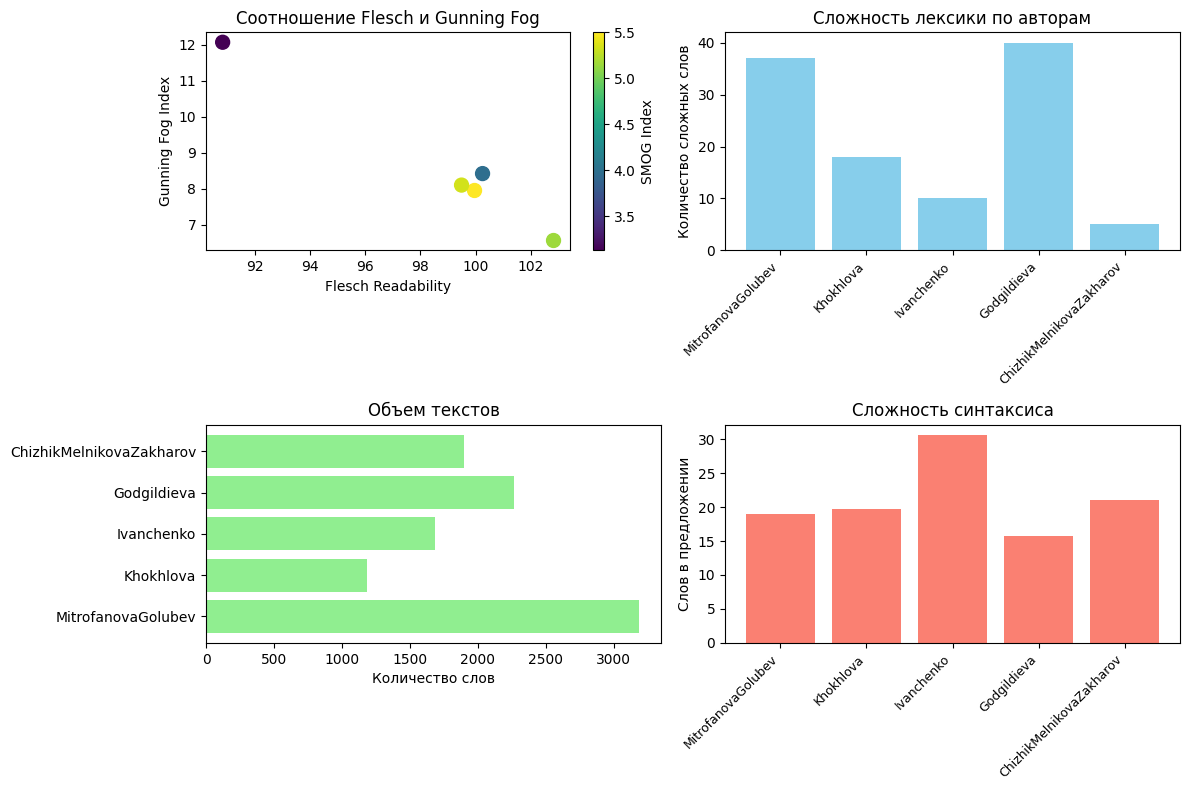

In [45]:
plt.figure(figsize=(12, 8))

# График 1: Соотношение Flesch и Gunning Fog
plt.subplot(2, 2, 1)
scatter = plt.scatter(df['flesch'], df['gunning_fog'], c=df['smog'], s=100, cmap='viridis')
plt.xlabel('Flesch Readability', fontsize=10)
plt.ylabel('Gunning Fog Index', fontsize=10)
plt.colorbar(scatter, label='SMOG Index')
plt.title('Соотношение Flesch и Gunning Fog', fontsize=12)

# График 2: Распределение сложных слов
plt.subplot(2, 2, 2)
plt.bar(df['author'], df['difficult_words'], color='skyblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Количество сложных слов', fontsize=10)
plt.title('Сложность лексики по авторам', fontsize=12)

# График 3: Длина текстов
plt.subplot(2, 2, 3)
plt.barh(df['author'], df['words'], color='lightgreen')
plt.xlabel('Количество слов', fontsize=10)
plt.title('Объем текстов', fontsize=12)

# График 4: Средняя длина предложения
plt.subplot(2, 2, 4)
df['words_per_sentence'] = df['words'] / df['sentences']
plt.bar(df['author'], df['words_per_sentence'], color='salmon')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Слов в предложении', fontsize=10)
plt.title('Сложность синтаксиса', fontsize=12)

plt.tight_layout()
plt.show()